# weather impact on dublin public transport

programming for data analytics. ca2.

---

this notebook measures how weather conditions in dublin affect ridership on public transport.
data sources: met eireann daily and monthly weather records. cso bus and luas passenger statistics.
covid years 2020 and 2021 are excluded from correlation calculations to avoid lockdown distortion.

> **note for colab users**: upload the `data/` folder to your colab session before running.
> in colab you can use the files panel on the left to drag and drop the folder.


## 1. setup


In [1]:
# load all libraries needed for data handling. statistics. and plotting.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, kruskal
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (14, 5), 'figure.dpi': 100,
                     'axes.titlesize': 12, 'axes.labelsize': 10})

DATA = 'data/'

# season mapping reused across all datasets.
season_map = {12: 'Winter', 1: 'Winter',  2: 'Winter',
              3:  'Spring', 4: 'Spring',  5: 'Spring',
              6:  'Summer', 7: 'Summer',  8: 'Summer',
              9:  'Autumn', 10: 'Autumn', 11: 'Autumn'}

print('libraries loaded.')

libraries loaded.


## 2. data loading and preparation

three separate data sources are loaded here. met eireann daily weather. met eireann monthly weather.
and cso passenger statistics for dublin bus and luas.
each file needs light cleaning because numeric fields come as strings and dates need parsing.


In [2]:
# daily weather from met eireann phoenix park station.
# the file has 24 rows of metadata at the top so we skip them.
# date strings are in dd-mmm-yyyy format. numeric columns sometimes contain spaces or dashes.

weather_daily = pd.read_csv(f'{DATA}met_eireann_dublin_daily.csv', skiprows=24)
weather_daily.columns = weather_daily.columns.str.strip()
weather_daily['date'] = pd.to_datetime(weather_daily['date'], format='%d-%b-%Y')

for c in ['maxtp', 'mintp', 'rain', 'wdsp', 'sun']:
    if c in weather_daily.columns:
        weather_daily[c] = pd.to_numeric(
            weather_daily[c].astype(str).str.strip(), errors='coerce')

weather_daily['year']     = weather_daily['date'].dt.year
weather_daily['month']    = weather_daily['date'].dt.month
weather_daily['avg_temp'] = (weather_daily['maxtp'] + weather_daily['mintp']) / 2
weather_daily['is_rainy'] = weather_daily['rain'] > 0.2
weather_daily['season']   = weather_daily['month'].map(season_map)

print(f"daily weather: {weather_daily.shape}. "
      f"range: {weather_daily['date'].min().date()} to {weather_daily['date'].max().date()}")
weather_daily[['rain', 'maxtp', 'mintp', 'avg_temp', 'wdsp', 'sun']].describe().round(2)

daily weather: (30740, 31). range: 1942-01-01 to 2026-02-28


,rain,maxtp,mintp,avg_temp,wdsp,sun
count,30740.00,30740.00,30740.00,30740.00,30740.00,30740.00
mean,2.08,13.08,6.16,9.62,10.17,4.01
std,4.40,4.91,4.38,4.46,4.58,3.76
min,0.00,-4.70,-12.20,-8.05,0.00,0.00
25%,0.00,9.40,2.90,6.25,6.80,0.50
50%,0.20,13.00,6.30,9.60,9.50,3.20
75%,2.20,16.90,9.60,13.15,13.00,6.50
max,92.60,29.10,18.40,22.45,35.50,15.90


In [3]:
# monthly aggregates from met eireann. 19 header rows to skip.
# meant is the mean temperature for the month.
# mnmax and mnmin are the averages of daily maximum and minimum temperatures.

weather_monthly = pd.read_csv(f'{DATA}met_eireann_dublin_monthly.csv', skiprows=19)
weather_monthly.columns = weather_monthly.columns.str.strip()

for c in ['meant', 'maxtp', 'mintp', 'mnmax', 'mnmin', 'rain', 'wdsp', 'sun']:
    if c in weather_monthly.columns:
        weather_monthly[c] = pd.to_numeric(
            weather_monthly[c].astype(str).str.strip(), errors='coerce')

weather_monthly['year']   = weather_monthly['year'].astype(int)
weather_monthly['month']  = weather_monthly['month'].astype(int)
weather_monthly['date']   = pd.to_datetime(
    weather_monthly['year'].astype(str) + '-' +
    weather_monthly['month'].astype(str) + '-01')
weather_monthly['season'] = weather_monthly['month'].map(season_map)

print(f"monthly weather: {weather_monthly.shape}. "
      f"range: {weather_monthly['date'].min().date()} to {weather_monthly['date'].max().date()}")
weather_monthly.tail()

monthly weather: (1011, 14). range: 1941-11-01 to 2026-01-01


,year,month,meant,maxtp,mintp,mnmax,mnmin,rain,gmin,wdsp,maxgt,sun,date,season
1006,2025,9,12.7,20.0,1.8,16.7,8.7,91.4,-2.1,8.2,42,130.6,2025-09-01,Autumn
1007,2025,10,11.2,19.7,3.0,13.8,8.6,90.0,-1.7,9.6,48,69.4,2025-10-01,Autumn
1008,2025,11,8.2,17.4,-2.3,11.3,5.1,119.1,-4.5,9.6,50,91.7,2025-11-01,Autumn
1009,2025,12,7.4,16.3,0.0,9.7,5.0,48.4,-4.6,10.1,52,59.3,2025-12-01,Winter
1010,2026,1,4.6,12.8,-3.9,7.2,1.9,137.7,-7.7,10.5,47,63.0,2026-01-01,Winter


In [4]:
# dublin bus monthly passengers from cso table toa14.
# filter out the all-months summary rows before working with the data.

bus_raw = pd.read_csv(f'{DATA}dublin_bus_monthly_passengers.csv')
bus = bus_raw[bus_raw['Month'] != 'All months'].copy()
bus['passengers'] = pd.to_numeric(bus['VALUE'], errors='coerce')
bus['year']       = bus['Year'].astype(int)
bus['month']      = bus['C01885V02316'].astype(int)
bus['date']       = pd.to_datetime(
    bus['year'].astype(str) + '-' + bus['month'].astype(str) + '-01')
bus['season']     = bus['month'].map(season_map)

# luas monthly from cso table toa11. red and green lines are separate rows.
# we create a combined total by summing both lines per month.

luas_raw = pd.read_csv(f'{DATA}luas_passenger_numbers.csv')
luas = luas_raw[luas_raw['Month'] != 'All months'].copy()
luas['passengers'] = pd.to_numeric(luas['VALUE'], errors='coerce')
luas['year']       = luas['Year'].astype(int)
luas['month']      = luas['C01885V02316'].astype(int)
luas['line']       = luas['Statistic Label']
luas['date']       = pd.to_datetime(
    luas['year'].astype(str) + '-' + luas['month'].astype(str) + '-01')
luas['season']     = luas['month'].map(season_map)

luas_total = (luas
    .groupby(['date', 'year', 'month', 'season'])
    .agg(passengers=('passengers', 'sum'))
    .reset_index())

print(f"dublin bus: {bus.shape[0]} months. {bus['year'].min()} to {bus['year'].max()}")
print(f"luas total: {luas_total.shape[0]} months. "
      f"{luas_total['year'].min()} to {luas_total['year'].max()}")

dublin bus: 132 months. 2014 to 2024
luas total: 84 months. 2018 to 2024


In [5]:
# quick missing-value check across all four datasets before starting the analysis.

datasets = {
    'daily weather':   weather_daily[['rain', 'maxtp', 'mintp', 'wdsp', 'sun']],
    'monthly weather': weather_monthly[['rain', 'meant', 'mnmax', 'mnmin', 'sun']],
    'dublin bus':      bus[['passengers']],
    'luas total':      luas_total[['passengers']],
}

rows = []
for name, df in datasets.items():
    total   = len(df)
    missing = df.isnull().sum().sum()
    pct     = (missing / (total * df.shape[1])) * 100
    rows.append({'dataset': name, 'rows': total, 'columns': df.shape[1],
                 'missing values': missing, 'missing %': round(pct, 2)})

print(pd.DataFrame(rows).to_string(index=False))

        dataset  rows  columns  missing values  missing %
  daily weather 30740        5               0        0.0
monthly weather  1011        5               0        0.0
     dublin bus   132        1               0        0.0
     luas total    84        1               0        0.0


## 3. dublin weather profile

before comparing weather with transport. we look at what dublin's climate actually looks like across the year.
monthly averages are computed from the daily data to smooth out year-to-year variation.


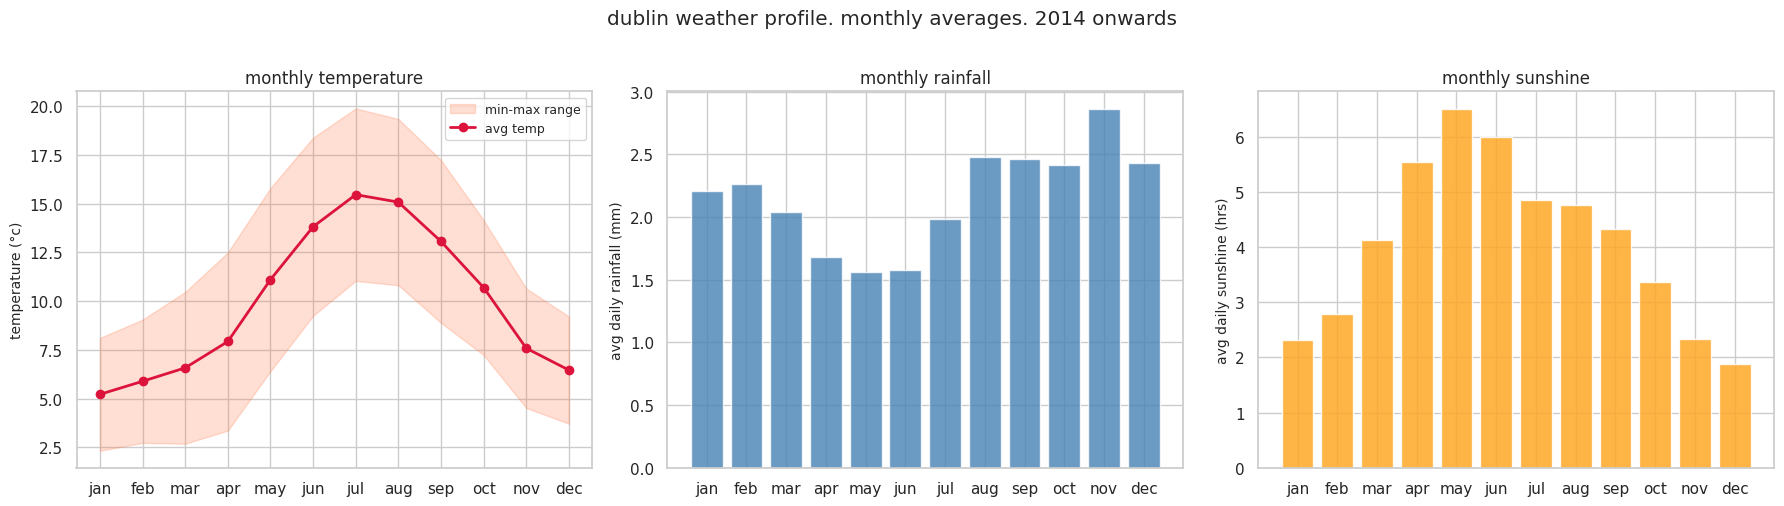

In [6]:
# compute monthly averages for temperature. rainfall. and sunshine using daily records from 2014 onwards.
# this gives a stable long-run picture of dublin's seasonal weather patterns.

wd = weather_daily[weather_daily['year'] >= 2014].copy()
mo_avg = wd.groupby('month').agg(
    rain=('rain', 'mean'), max_t=('maxtp', 'mean'), min_t=('mintp', 'mean'),
    avg_t=('avg_temp', 'mean'), wind=('wdsp', 'mean'), sun=('sun', 'mean'),
    rainy_pct=('is_rainy', 'mean')
).reset_index()

month_labels = ['jan','feb','mar','apr','may','jun',
                'jul','aug','sep','oct','nov','dec']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# temperature band showing the typical min-max spread.
ax = axes[0]
ax.fill_between(range(12), mo_avg['min_t'], mo_avg['max_t'],
                alpha=0.25, color='coral', label='min-max range')
ax.plot(range(12), mo_avg['avg_t'], 'o-', color='crimson', lw=2, label='avg temp')
ax.set_xticks(range(12)); ax.set_xticklabels(month_labels)
ax.set(ylabel='temperature (°c)', title='monthly temperature')
ax.legend(fontsize=9)

# average daily rainfall by month.
ax = axes[1]
ax.bar(range(12), mo_avg['rain'], color='steelblue', alpha=0.8)
ax.set_xticks(range(12)); ax.set_xticklabels(month_labels)
ax.set(ylabel='avg daily rainfall (mm)', title='monthly rainfall')

# average daily sunshine hours by month.
ax = axes[2]
ax.bar(range(12), mo_avg['sun'], color='#FFA726', alpha=0.85)
ax.set_xticks(range(12)); ax.set_xticklabels(month_labels)
ax.set(ylabel='avg daily sunshine (hrs)', title='monthly sunshine')

plt.suptitle('dublin weather profile. monthly averages. 2014 onwards', y=1.01)
plt.tight_layout()
plt.show()

## 4. transport ridership over time

monthly passenger numbers for dublin bus and luas plotted over the full available period.
the shaded band marks covid lockdown years 2020 and 2021 which are excluded from correlations.


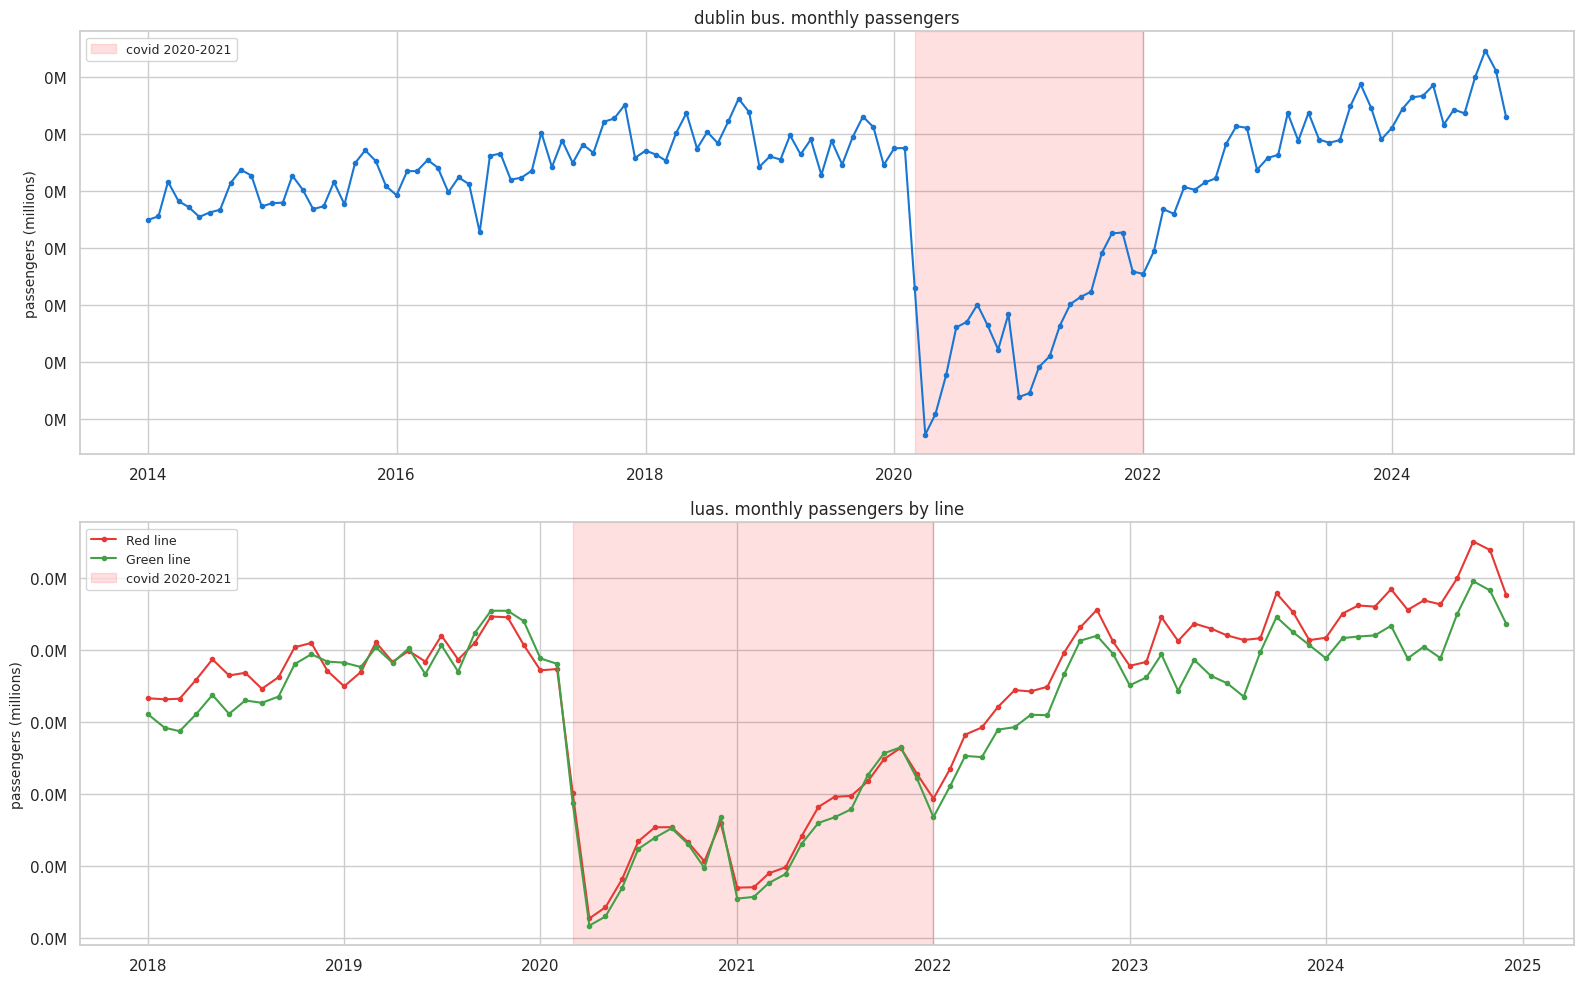

In [7]:
# monthly ridership plotted separately for bus and luas.
# covid years are shaded so the viewer can see how severe the drop was and how recovery progressed.

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

# dublin bus monthly.
ax = axes[0]
ax.plot(bus['date'], bus['passengers'] / 1e6, 'o-', ms=3, color='#1976D2', lw=1.5)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
           alpha=0.12, color='red', label='covid 2020-2021')
ax.set(ylabel='passengers (millions)', title='dublin bus. monthly passengers')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# luas split by line.
ax = axes[1]
for ln, clr in [('Red line', '#E53935'), ('Green line', '#43A047')]:
    d = luas[luas['line'] == ln]
    ax.plot(d['date'], d['passengers'] / 1e6, 'o-', ms=3, color=clr, lw=1.5, label=ln)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
           alpha=0.12, color='red', label='covid 2020-2021')
ax.set(ylabel='passengers (millions)', title='luas. monthly passengers by line')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

## 5. weather and ridership. correlation analysis

monthly weather is merged with monthly passenger data on year and month.
pearson r measures linear association. spearman r is rank-based and more robust to outliers.
both are reported together with the p-value so we can judge statistical significance.


In [8]:
# merge weather and transport data on year and month. remove covid years before correlating.

bw = bus.merge(
    weather_monthly[['year', 'month', 'rain', 'meant', 'wdsp', 'sun']],
    on=['year', 'month'], how='inner')
bw_nc = bw[~bw['year'].isin([2020, 2021])].copy()

lw = luas_total.merge(
    weather_monthly[['year', 'month', 'rain', 'meant', 'wdsp', 'sun']],
    on=['year', 'month'], how='inner')
lw_nc = lw[~lw['year'].isin([2020, 2021])].copy()

# compute pearson and spearman for each weather variable. collect results in a table.
def corr_table(df, label):
    variables = {'rain':  'rainfall (mm)',
                 'meant': 'mean temp (c)',
                 'wdsp':  'wind speed (kt)',
                 'sun':   'sunshine (hrs)'}
    rows = []
    for col, name in variables.items():
        v       = df.dropna(subset=[col, 'passengers'])
        rp, pp  = pearsonr(v[col], v['passengers'])
        rs, ps  = spearmanr(v[col], v['passengers'])
        sig     = '***' if pp < 0.001 else '**' if pp < 0.01 else '*' if pp < 0.05 else 'ns'
        rows.append({'transport': label, 'variable': name,
                     'pearson r': round(rp, 3), 'p-value': round(pp, 4),
                     'spearman r': round(rs, 3), 'significant': sig})
    return pd.DataFrame(rows)

result = pd.concat([corr_table(bw_nc, 'dublin bus'), corr_table(lw_nc, 'luas')])
print(result.to_string(index=False))

 transport        variable  pearson r  p-value  spearman r significant
dublin bus   rainfall (mm)      0.075   0.4411       0.109          ns
dublin bus   mean temp (c)      0.106   0.2748       0.115          ns
dublin bus wind speed (kt)     -0.292   0.0022      -0.246          **
dublin bus  sunshine (hrs)     -0.084   0.3875      -0.104          ns
      luas   rainfall (mm)      0.241   0.0636       0.276          ns
      luas   mean temp (c)      0.114   0.3874       0.067          ns
      luas wind speed (kt)     -0.198   0.1300      -0.039          ns
      luas  sunshine (hrs)     -0.217   0.0958      -0.256          ns


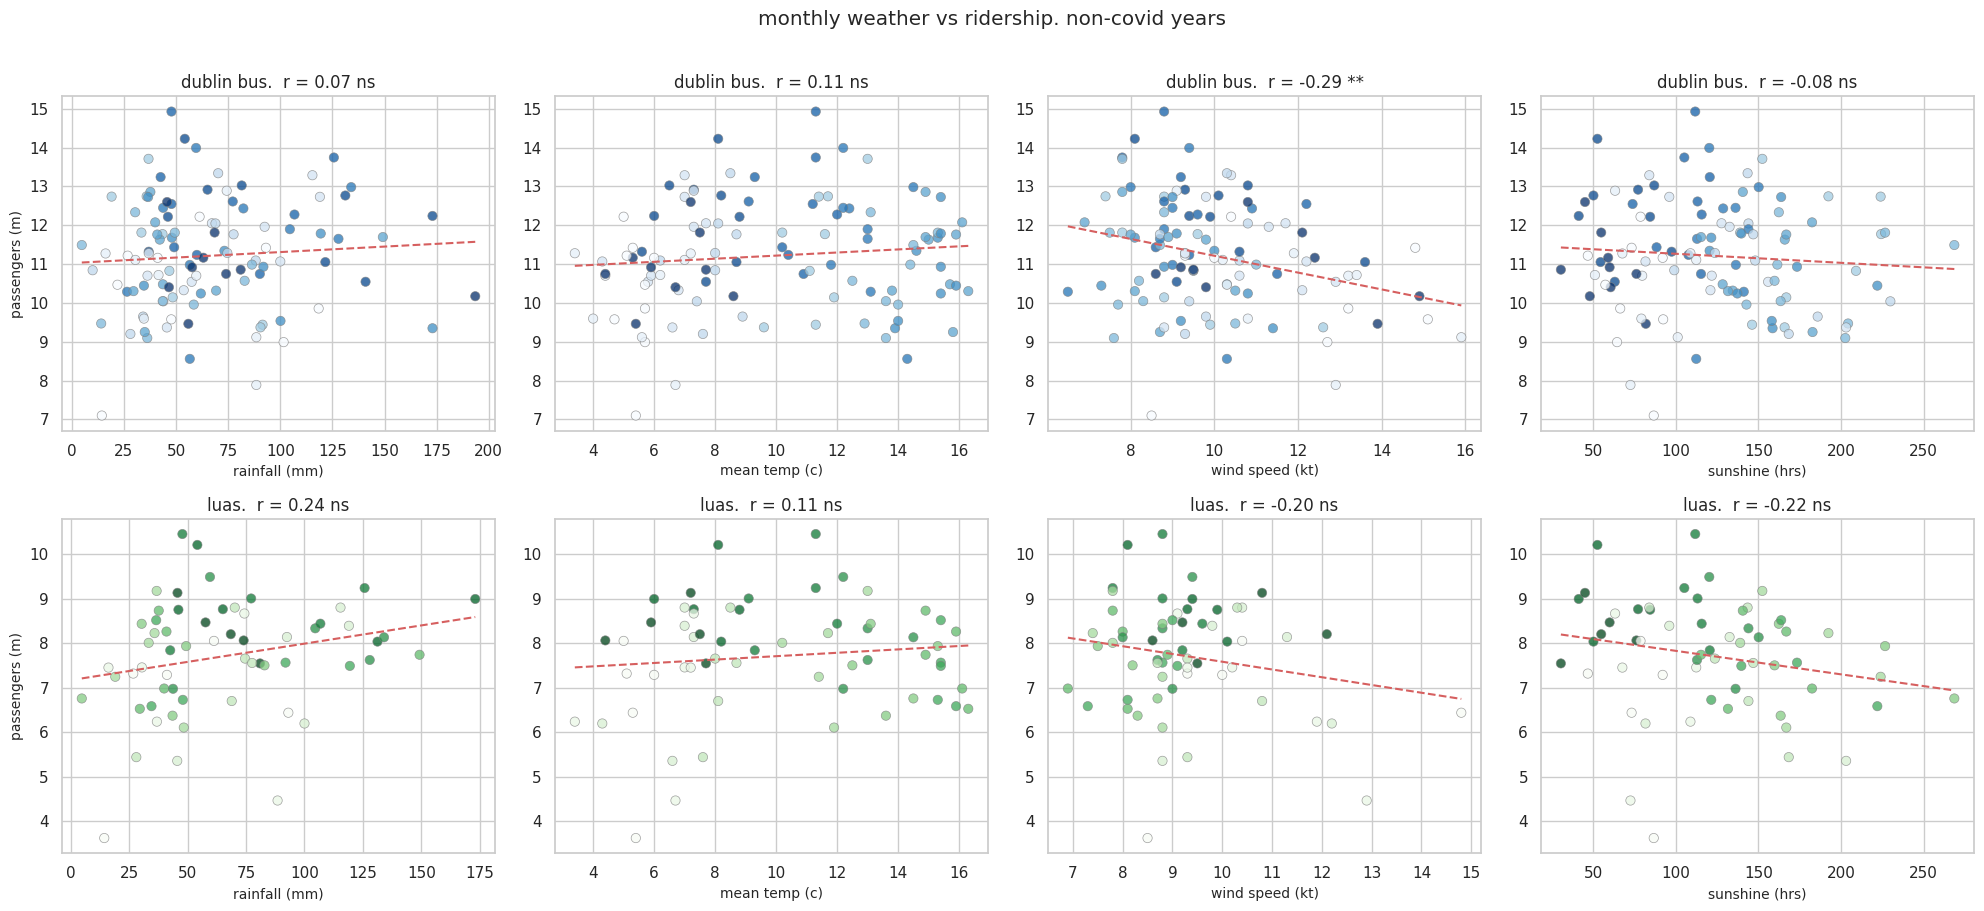

In [9]:
# scatter plot for each weather variable vs monthly passengers. both bus and luas.
# a first-degree polynomial trend line is fitted using numpy polyfit.
# month number is used as colour so seasonal clustering becomes visible.

weather_vars = [('rain',  'rainfall (mm)'),
                ('meant', 'mean temp (c)'),
                ('wdsp',  'wind speed (kt)'),
                ('sun',   'sunshine (hrs)')]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for i, (col, lab) in enumerate(weather_vars):
    for row, (df, title, cmap) in enumerate([
            (bw_nc, 'dublin bus', 'Blues'),
            (lw_nc, 'luas',       'Greens')]):
        ax = axes[row, i]
        v  = df.dropna(subset=[col, 'passengers'])
        ax.scatter(v[col], v['passengers'] / 1e6, c=v['month'],
                   cmap=cmap, s=45, alpha=0.75, edgecolors='gray', linewidth=0.5)
        z  = np.polyfit(v[col], v['passengers'] / 1e6, 1)
        xl = np.linspace(v[col].min(), v[col].max(), 50)
        ax.plot(xl, np.polyval(z, xl), 'r--', lw=1.5)
        rp, pp = pearsonr(v[col], v['passengers'])
        sig    = '***' if pp < 0.001 else '**' if pp < 0.01 else '*' if pp < 0.05 else 'ns'
        ax.set(xlabel=lab,
               ylabel='passengers (m)' if i == 0 else '',
               title=f'{title}.  r = {rp:.2f} {sig}')

plt.suptitle('monthly weather vs ridership. non-covid years', y=1.01)
plt.tight_layout()
plt.show()

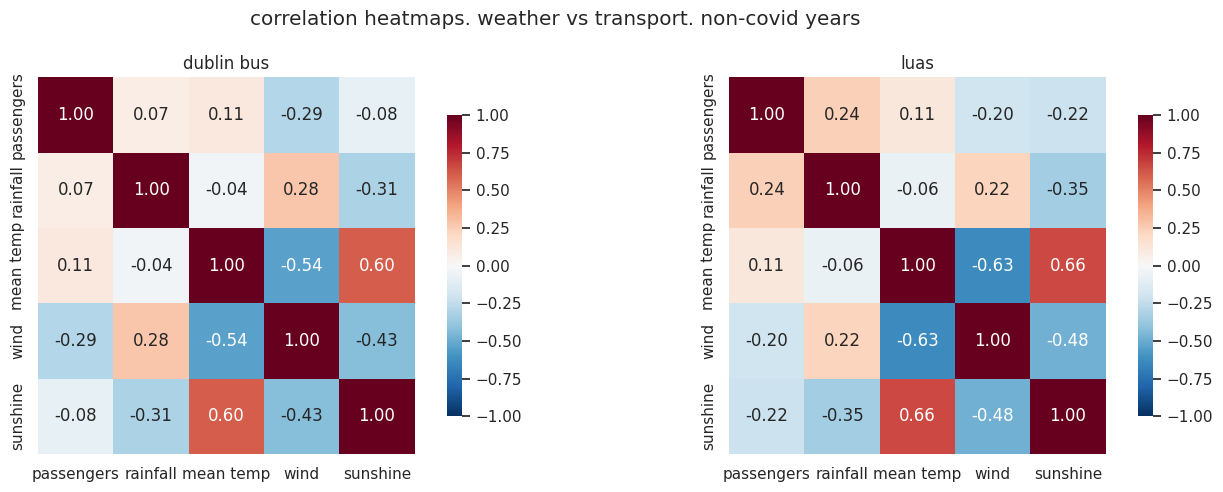

In [10]:
# full correlation matrix for each transport mode.
# red-blue diverging scale. values near 1 or -1 indicate stronger linear relationships.

corr_cols  = ['passengers', 'rain', 'meant', 'wdsp', 'sun']
col_labels = ['passengers', 'rainfall', 'mean temp', 'wind', 'sunshine']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in [(axes[0], bw_nc, 'dublin bus'),
                      (axes[1], lw_nc, 'luas')]:
    c = df[corr_cols].corr()
    c.index   = col_labels
    c.columns = col_labels
    sns.heatmap(c, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(title)

plt.suptitle('correlation heatmaps. weather vs transport. non-covid years')
plt.tight_layout()
plt.show()

## 6. seasonal patterns

months grouped into four seasons. average ridership compared across seasons.
weather averages per season are shown alongside so both sides of the relationship are visible.


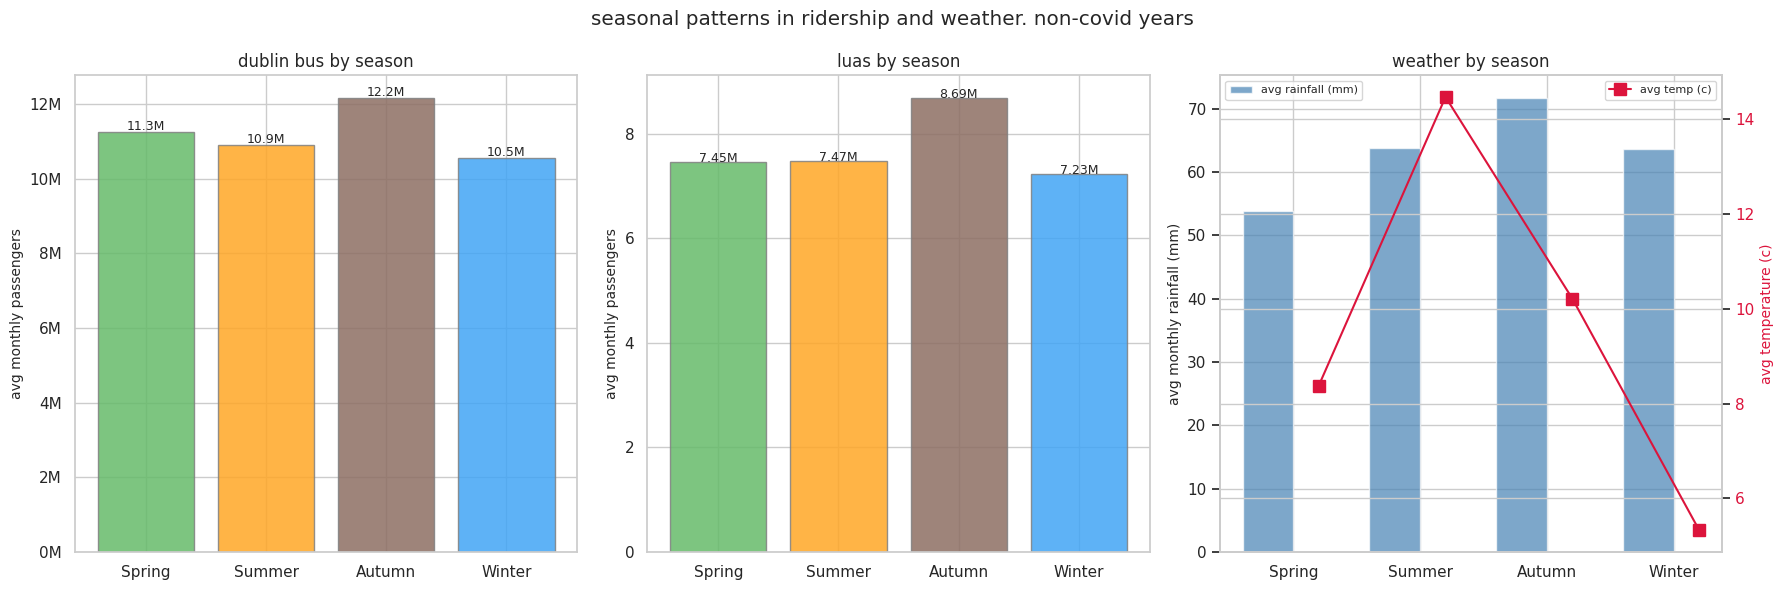

In [11]:
# average monthly ridership by season. bar charts for bus and luas.
# the third panel shows average rainfall and temperature per season for comparison.

season_labels = ['Spring', 'Summer', 'Autumn', 'Winter']
colors        = ['#66BB6A', '#FFA726', '#8D6E63', '#42A5F5']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# bus by season.
ax = axes[0]
s  = bw_nc.groupby('season')['passengers'].mean().reindex(season_labels) / 1e6
bars = ax.bar(season_labels, s, color=colors, edgecolor='gray', alpha=0.85)
for b, v in zip(bars, s):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.05,
            f'{v:.1f}M', ha='center', fontsize=9)
ax.set(ylabel='avg monthly passengers', title='dublin bus by season')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

# luas by season.
ax = axes[1]
s  = lw_nc.groupby('season')['passengers'].mean().reindex(season_labels) / 1e6
bars = ax.bar(season_labels, s, color=colors, edgecolor='gray', alpha=0.85)
for b, v in zip(bars, s):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.005,
            f'{v:.2f}M', ha='center', fontsize=9)
ax.set(ylabel='avg monthly passengers', title='luas by season')

# average rainfall and mean temperature per season.
sw     = weather_monthly[~weather_monthly['year'].isin([2020, 2021])].copy()
sw_avg = sw.groupby('season').agg(
    rain=('rain', 'mean'), temp=('meant', 'mean')).reindex(season_labels)
x   = np.arange(len(season_labels))
ax  = axes[2]
ax2 = ax.twinx()
ax.bar(x - 0.2, sw_avg['rain'], width=0.4, color='steelblue',
       alpha=0.7, label='avg rainfall (mm)')
ax2.plot(x + 0.2, sw_avg['temp'], 's-', color='crimson', ms=8, label='avg temp (c)')
ax.set_xticks(x); ax.set_xticklabels(season_labels)
ax.set(ylabel='avg monthly rainfall (mm)', title='weather by season')
ax.legend(loc='upper left', fontsize=8)
ax2.set_ylabel('avg temperature (c)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.legend(loc='upper right', fontsize=8)

plt.suptitle('seasonal patterns in ridership and weather. non-covid years')
plt.tight_layout()
plt.show()

## 7. statistical significance. kruskal-wallis test

months are split into three equal-sized groups by rainfall and by temperature using quantile-based binning.
the kruskal-wallis test is a non-parametric equivalent of anova.
a low p-value means ridership differs significantly across the groups.


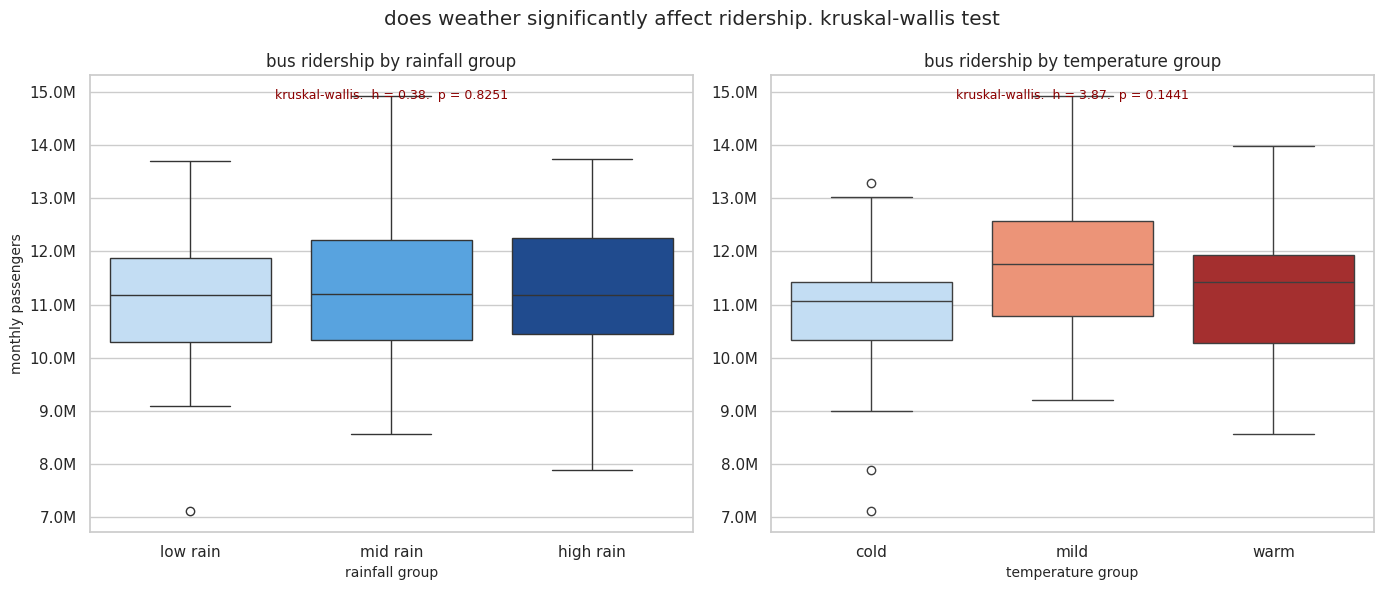

rainfall groups.    h = 0.384.  p = 0.8251
temperature groups. h = 3.874.  p = 0.1441


In [12]:
# divide months into low. mid. and high rainfall thirds using quantile cut.
# same approach for temperature. then compare ridership distributions with kruskal-wallis.

bw_nc = bw_nc.copy()
bw_nc['rain_group'] = pd.qcut(bw_nc['rain'], 3,
                               labels=['low rain', 'mid rain', 'high rain'])
bw_nc['temp_group'] = pd.qcut(bw_nc['meant'], 3,
                               labels=['cold', 'mild', 'warm'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# boxplot for rainfall groups.
ax      = axes[0]
order_r = ['low rain', 'mid rain', 'high rain']
sns.boxplot(data=bw_nc, x='rain_group', y='passengers',
            order=order_r, ax=ax, palette=['#BBDEFB', '#42A5F5', '#0D47A1'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
g_rain  = [bw_nc.loc[bw_nc['rain_group'] == g, 'passengers'].dropna().values
           for g in order_r]
h_r, p_r = kruskal(*g_rain)
ax.set(xlabel='rainfall group', ylabel='monthly passengers',
       title='bus ridership by rainfall group')
ax.text(0.5, 0.97, f'kruskal-wallis.  h = {h_r:.2f}.  p = {p_r:.4f}',
        transform=ax.transAxes, ha='center', va='top', fontsize=9, color='darkred')

# boxplot for temperature groups.
ax      = axes[1]
order_t = ['cold', 'mild', 'warm']
sns.boxplot(data=bw_nc, x='temp_group', y='passengers',
            order=order_t, ax=ax, palette=['#BBDEFB', '#FF8A65', '#B71C1C'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
g_temp  = [bw_nc.loc[bw_nc['temp_group'] == g, 'passengers'].dropna().values
           for g in order_t]
h_t, p_t = kruskal(*g_temp)
ax.set(xlabel='temperature group', ylabel='',
       title='bus ridership by temperature group')
ax.text(0.5, 0.97, f'kruskal-wallis.  h = {h_t:.2f}.  p = {p_t:.4f}',
        transform=ax.transAxes, ha='center', va='top', fontsize=9, color='darkred')

plt.suptitle('does weather significantly affect ridership. kruskal-wallis test')
plt.tight_layout()
plt.show()

print(f'rainfall groups.    h = {h_r:.3f}.  p = {p_r:.4f}')
print(f'temperature groups. h = {h_t:.3f}.  p = {p_t:.4f}')

## 8. timeline overlay. transport and weather

bus passengers. monthly rainfall. and mean temperature plotted on a shared time axis.
seasonal co-movement between these series gives a direct visual picture of the weather effect.


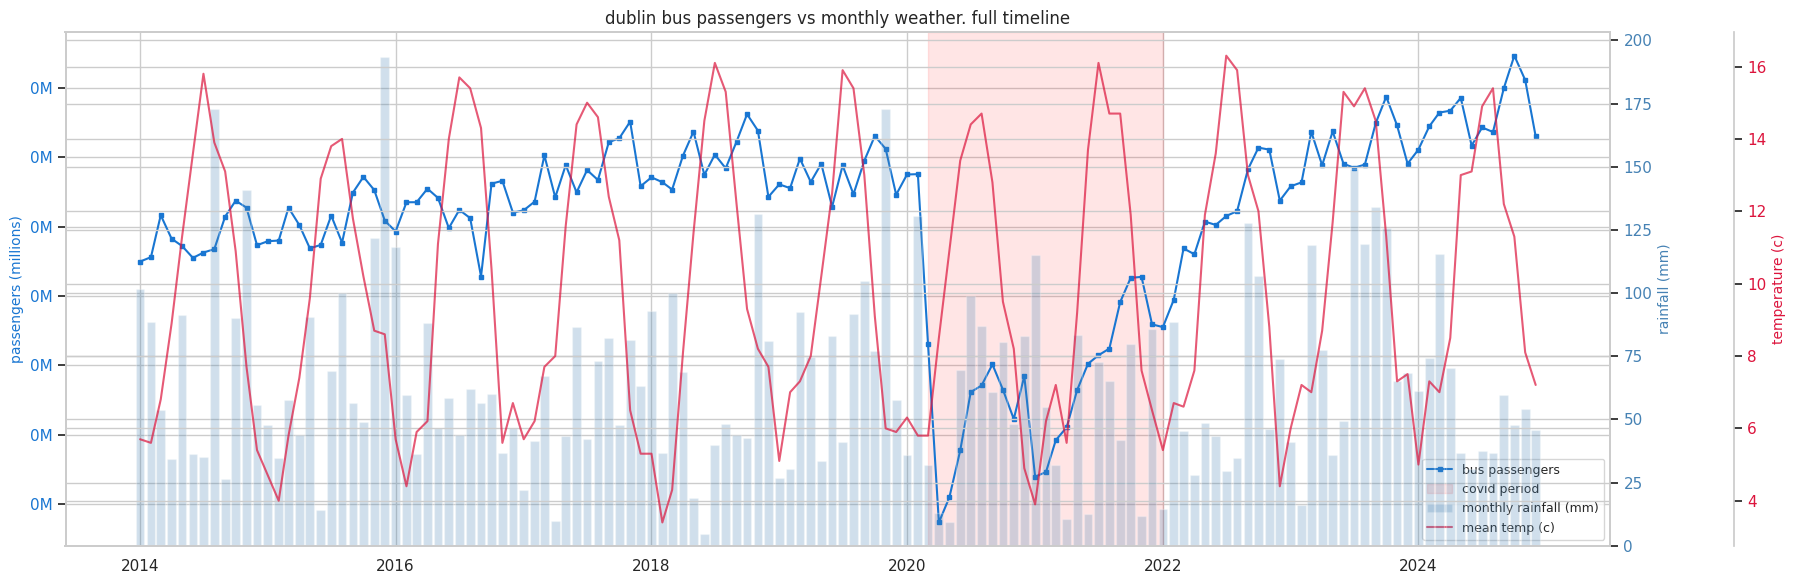

In [13]:
# three axes share the same x-axis. passengers on the left. rainfall bars and temperature on the right.
# the offset spine for the temperature axis prevents the labels overlapping.

fig, ax1 = plt.subplots(figsize=(18, 6))

ax1.plot(bw['date'], bw['passengers'] / 1e6, 's-',
         color='#1976D2', lw=1.5, ms=3, label='bus passengers')
ax1.set_ylabel('passengers (millions)', color='#1976D2')
ax1.tick_params(axis='y', labelcolor='#1976D2')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax1.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
            alpha=0.10, color='red', label='covid period')

ax2 = ax1.twinx()
ax2.bar(bw['date'], bw['rain'], width=25, alpha=0.25,
        color='steelblue', label='monthly rainfall (mm)')
ax2.set_ylabel('rainfall (mm)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('axes', 1.08))
ax3.plot(bw['date'], bw['meant'], '-',
         color='crimson', lw=1.5, alpha=0.7, label='mean temp (c)')
ax3.set_ylabel('temperature (c)', color='crimson')
ax3.tick_params(axis='y', labelcolor='crimson')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
h3, l3 = ax3.get_legend_handles_labels()
ax1.legend(h1 + h2 + h3, l1 + l2 + l3, loc='lower right', fontsize=9)

plt.title('dublin bus passengers vs monthly weather. full timeline')
plt.tight_layout()
plt.show()

## 9. summary of findings

the table below brings together the key correlation coefficients and significance levels
from the monthly analysis for both dublin bus and luas.


In [14]:
# print all correlation results in one place.
# significance codes: *** p<0.001.  ** p<0.01.  * p<0.05.  ns not significant.

print('weather impact on dublin public transport. summary of correlations.')
print('=' * 65)
print('non-covid months only. pearson r with p-values.')
print()

for transport_name, df in [('dublin bus', bw_nc), ('luas', lw_nc)]:
    print(f'{transport_name.upper()}')
    for col, lab in [('rain',  'rainfall   '),
                     ('meant', 'temperature'),
                     ('wdsp',  'wind speed '),
                     ('sun',   'sunshine   ')]:
        v = df.dropna(subset=[col, 'passengers'])
        if len(v) < 5:
            continue
        r, p = pearsonr(v[col], v['passengers'])
        sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f'  {lab}   r = {r:+.3f}   p = {p:.4f}   {sig}')
    print()

weather impact on dublin public transport. summary of correlations.
non-covid months only. pearson r with p-values.

DUBLIN BUS
  rainfall      r = +0.075   p = 0.4411   ns
  temperature   r = +0.106   p = 0.2748   ns
  wind speed    r = -0.292   p = 0.0022   **
  sunshine      r = -0.084   p = 0.3875   ns

LUAS
  rainfall      r = +0.241   p = 0.0636   ns
  temperature   r = +0.114   p = 0.3874   ns
  wind speed    r = -0.198   p = 0.1300   ns
  sunshine      r = -0.217   p = 0.0958   ns

